In [1]:
# imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

In [2]:
# loading files

ipca = pd.read_csv('ipca.csv', parse_dates=['data'], index_col='data')
cpi  = pd.read_csv('us_cpi.csv', parse_dates=['date'], index_col='date')
fx   = pd.read_csv('usd_brl_monthly.csv', parse_dates=['data'], index_col='data')

In [3]:
# monthly frequency

ipca = ipca.asfreq('MS')  # 'MS' = início do mês
cpi  = cpi.asfreq('MS')
fx   = fx.asfreq('MS')

In [4]:
# selecting only date + monthly value columns and renaming them for easier handling

cpi_clean = cpi[['value']].rename(columns={'value': 'us_cpi'})
ipca_clean = ipca[['valor']].rename(columns={'valor': 'ipca'})
fx_clean = fx[['valor_ultimo_mes']].rename(columns={'valor_ultimo_mes': 'usd_brl'})

In [5]:
df = ipca_clean.join(cpi_clean, how='left').join(fx_clean, how='left')

In [6]:
df.head()

,ipca,us_cpi,usd_brl
data,,,
2000-01-01,0.62,168.8,1.8024
2000-02-01,0.13,169.8,1.7685
2000-03-01,0.22,171.2,1.7473
2000-04-01,0.42,171.3,1.8067
2000-05-01,0.01,171.5,1.8266


In [ ]:
# 1. Transform in monthly variations
# IPCA - already in monthly variation, so we just need to rename the column for easier handling
# CPI and USD/BRL - we need to calculate the monthly variation and then rename the columns

df = df.sort_index().copy()  # sort by date (index) and create a copy to avoid SettingWithCopyWarning

df['us_cpi_pct']  = df['us_cpi'].pct_change() * 100
df['usd_brl_pct'] = df['usd_brl'].pct_change() * 100
df['ipca_pct']    = df['ipca']   # já em variação percentual

df_model = (
    df[['ipca_pct', 'us_cpi_pct', 'usd_brl_pct']]
    .dropna()
    .reset_index(drop=True)
)

print(f"Observações após transformação: {len(df_model)}")
print(df_model.tail())


Observações após transformação: 299
     ipca_pct  us_cpi_pct  usd_brl_pct
294     -0.02    0.081389    -0.104202
295      0.44    0.160421    -3.679149
296      0.56    0.115128     6.053487
297      0.39   -0.054172     4.769899
298      0.52    0.035500     2.292888


In [8]:
# checking data after transformations
df.head()

,ipca,us_cpi,usd_brl,us_cpi_pct,usd_brl_pct,ipca_pct
data,,,,,,
2000-01-01,0.62,168.8,1.8024,NaN,NaN,0.62
2000-02-01,0.13,169.8,1.7685,0.592417,-1.880826,0.13
2000-03-01,0.22,171.2,1.7473,0.824499,-1.198756,0.22
2000-04-01,0.42,171.3,1.8067,0.058411,3.399531,0.42
2000-05-01,0.01,171.5,1.8266,0.116754,1.101456,0.01


us_cpi_pct: lags significativos a 5% → [3, 4]
usd_brl_pct: lags significativos a 5% → [2, 4, 5, 6]


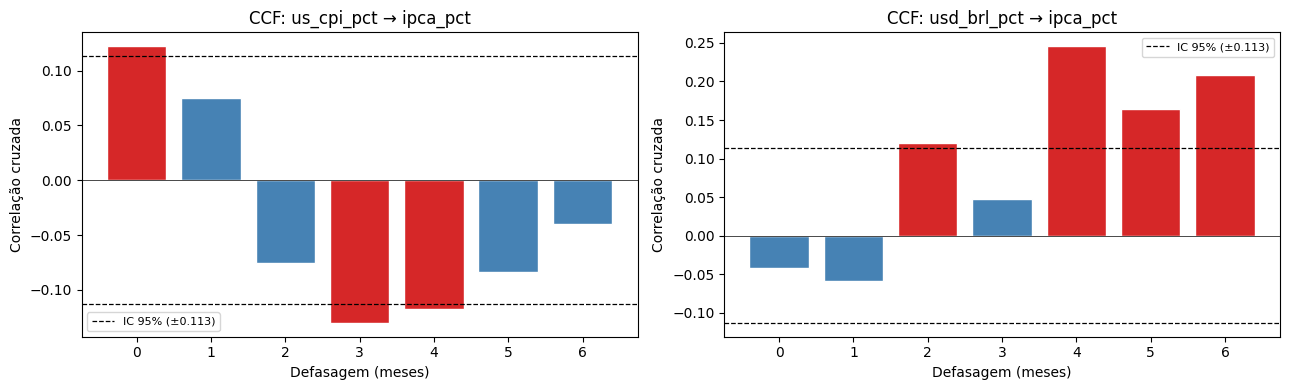

In [9]:
# 2. CCF - cross correlation function

MAX_LAGS = 6

def cross_corr(x: np.ndarray, y: np.ndarray, lag: int) -> float:
    """Correlação entre x_{t-lag} e y_t (x lidera y por `lag` períodos)."""
    x_std = (x - x.mean()) / x.std()
    y_std = (y - y.mean()) / y.std()
    if lag == 0:
        return float(np.corrcoef(x_std, y_std)[0, 1])
    return float(np.corrcoef(x_std[:-lag], y_std[lag:])[0, 1])

target = df_model['ipca_pct'].values
predictors = {
    'us_cpi_pct':  df_model['us_cpi_pct'].values,
    'usd_brl_pct': df_model['usd_brl_pct'].values,
}

n  = len(target)
ci = 1.96 / np.sqrt(n)   # intervalo de confiança 95% assintótico

sig_lags_ccf: dict[str, list[int]] = {}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, x) in zip(axes, predictors.items()):
    lags  = np.arange(0, MAX_LAGS + 1)
    corrs = np.array([cross_corr(x, target, k) for k in lags])
    colors = ['tab:red' if abs(c) > ci else 'steelblue' for c in corrs]

    ax.bar(lags, corrs, color=colors, edgecolor='white')
    ax.axhline( ci, color='k', linestyle='--', linewidth=0.9, label=f'IC 95% (±{ci:.3f})')
    ax.axhline(-ci, color='k', linestyle='--', linewidth=0.9)
    ax.axhline(0,   color='k', linewidth=0.5)
    ax.set_title(f'CCF: {name} → ipca_pct')
    ax.set_xlabel('Defasagem (meses)')
    ax.set_ylabel('Correlação cruzada')
    ax.set_xticks(lags)
    ax.legend(fontsize=8)

    sig = [int(k) for k, c in zip(lags[1:], corrs[1:]) if abs(c) > ci]
    sig_lags_ccf[name] = sig
    print(f"{name}: lags significativos a 5% → {sig if sig else 'nenhum'}")

plt.tight_layout()
plt.savefig('ccf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# 3. ARIMAX – AIC / BIC selection
# search grade: (p, q) ∈ {0,1,2}² and external lags ∈ {1,...,6}
# d=0: stationary series (% variation)

ARIMA_P  = [0, 1, 2]
ARIMA_Q  = [0, 1, 2]
LAG_RANGE = range(1, MAX_LAGS + 1)

records = []

for p, q, lag_cpi, lag_fx in product(ARIMA_P, ARIMA_Q, LAG_RANGE, LAG_RANGE):
    exog = pd.DataFrame({
        f'cpi_lag{lag_cpi}': df_model['us_cpi_pct'].shift(lag_cpi),
        f'fx_lag{lag_fx}':   df_model['usd_brl_pct'].shift(lag_fx),
    })
    mask   = exog.notna().all(axis=1)
    endog  = df_model.loc[mask, 'ipca_pct']
    exog_f = exog[mask]

    if len(endog) < 20:
        continue

    try:
        res = SARIMAX(
            endog, exog=exog_f, order=(p, 0, q),
            enforce_stationarity=False, enforce_invertibility=False
        ).fit(disp=False)

        records.append({
            'p': p, 'q': q,
            'lag_cpi': lag_cpi, 'lag_fx': lag_fx,
            'aic': res.aic, 'bic': res.bic,
            'n_obs': int(mask.sum()),
        })
    except Exception:
        continue

results_df = pd.DataFrame(records)

print("\n── Top 10 por AIC ──")
print(results_df.sort_values('aic').head(10).to_string(index=False))

print("\n── Top 10 por BIC ──")
print(results_df.sort_values('bic').head(10).to_string(index=False))

best_aic = results_df.sort_values('aic').iloc[0]
best_bic = results_df.sort_values('bic').iloc[0]


── Top 10 por AIC ──
 p  q  lag_cpi  lag_fx        aic        bic  n_obs
 2  2        2       4 129.585436 155.322712    295
 2  2        1       4 129.617879 155.355155    295
 2  2        6       2 129.759667 155.448834    293
 2  2        6       3 129.825311 155.514478    293
 2  2        6       4 130.329079 156.018246    293
 2  2        4       4 130.376108 156.113385    295
 2  2        3       4 131.040015 156.777292    295
 2  2        5       4 133.914642 159.627905    294
 2  1        5       3 134.648161 156.708684    294
 2  2        4       2 134.854083 160.591359    295

── Top 10 por BIC ──
 p  q  lag_cpi  lag_fx        aic        bic  n_obs
 2  2        2       4 129.585436 155.322712    295
 2  2        1       4 129.617879 155.355155    295
 2  2        6       2 129.759667 155.448834    293
 2  2        6       3 129.825311 155.514478    293
 2  2        6       4 130.329079 156.018246    293
 2  2        4       4 130.376108 156.113385    295
 2  1        5      

In [11]:
# 4. final consolidation of lag choices
print("\n" + "="*55)
print("RESUMO DAS DEFASAGENS IDENTIFICADAS")
print("="*55)

for var, key in [('us_cpi_pct', 'cpi'), ('usd_brl_pct', 'fx')]:
    ccf_result = sig_lags_ccf[var]
    lag_aic    = int(best_aic[f'lag_{key}'])
    lag_bic    = int(best_bic[f'lag_{key}'])

    if lag_aic == lag_bic:
        ic_choice = lag_aic
        ic_note   = f"AIC = BIC → lag {ic_choice}"
    else:
        ic_choice = lag_aic   # AIC como referência formal (conforme metodologia)
        ic_note   = f"AIC → lag {lag_aic} | BIC → lag {lag_bic} (divergência)"

    convergence = ic_choice in ccf_result

    print(f"\n{var}:")
    print(f"  CCF sig. (5%):   {ccf_result if ccf_result else 'nenhum'}")
    print(f"  Critério info.:  {ic_note}")
    if convergence:
        print(f"  → Defasagem final: {ic_choice}  ✓ (convergência AIC/CCF)")
    else:
        print(f"  → Defasagem final: {ic_choice}  ⚠ (sem convergência CCF — avaliar literatura)")




RESUMO DAS DEFASAGENS IDENTIFICADAS

us_cpi_pct:
  CCF sig. (5%):   [3, 4]
  Critério info.:  AIC = BIC → lag 2
  → Defasagem final: 2  ⚠ (sem convergência CCF — avaliar literatura)

usd_brl_pct:
  CCF sig. (5%):   [2, 4, 5, 6]
  Critério info.:  AIC = BIC → lag 4
  → Defasagem final: 4  ✓ (convergência AIC/CCF)


In [19]:
# saving final dataset with selected lags for future modeling steps

df_final = df[['ipca_pct', 'us_cpi_pct', 'usd_brl_pct']].copy()

# recommended lags based on the previous analysis (CCF + AIC/BIC)
df_final['us_cpi_lag2'] = df_final['us_cpi_pct'].shift(2)  # escolha do AIC
df_final['us_cpi_lag3'] = df_final['us_cpi_pct'].shift(3)  # limiar da CCF
df_final['usd_brl_lag4'] = df_final['usd_brl_pct'].shift(4)

df_final = df_final.dropna()
df_final = df_final.drop(columns=['us_cpi_pct', 'usd_brl_pct'])
df_final.head()

,ipca_pct,us_cpi_lag2,us_cpi_lag3,usd_brl_lag4
data,,,,
2000-06-01,0.23,0.058411,0.824499,-1.880826
2000-07-01,1.61,0.116754,0.058411,-1.198756
2000-08-01,1.31,0.524781,0.116754,3.399531
2000-09-01,0.23,0.232019,0.524781,1.101456
2000-10-01,0.14,0.000000,0.232019,-1.456258


In [20]:
# creating csv for the final dataset

df_final.to_csv('final_df_with_lags.csv', index=True)